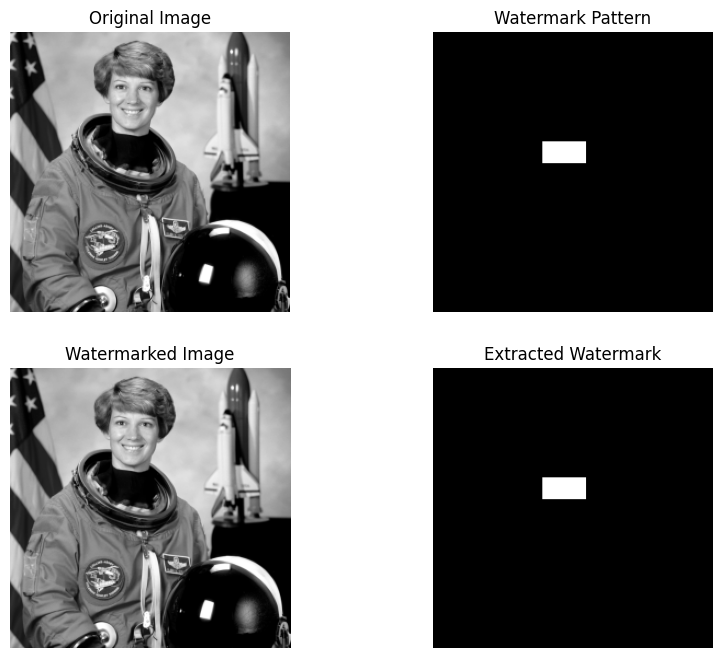

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.transform import resize

# Step 1: Load a sample grayscale image
image = color.rgb2gray(data.astronaut())   # astronaut image from skimage
image = resize(image, (256, 256))          # resize for simplicity

# Step 2: Create a simple watermark (text or pattern)
watermark = np.zeros_like(image)
watermark[100:120, 100:140] = 1            # a white rectangle watermark

# Step 3: Apply Fourier Transform to the image
f_transform = np.fft.fft2(image)
f_shift = np.fft.fftshift(f_transform)

# Step 4: Embed watermark in frequency domain
alpha = 0.1                                # strength of watermark
f_shift_watermarked = f_shift + alpha * watermark

# Step 5: Inverse Fourier Transform to get watermarked image
f_ishift = np.fft.ifftshift(f_shift_watermarked)
image_watermarked = np.fft.ifft2(f_ishift)
image_watermarked = np.real(image_watermarked)

# Step 6: Extract watermark (difference in frequency domain)
extracted = (f_shift_watermarked - f_shift) / alpha

# Step 7: Plot results
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Watermark Pattern")
plt.imshow(watermark, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Watermarked Image")
plt.imshow(image_watermarked, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Extracted Watermark")
plt.imshow(np.abs(extracted), cmap='gray')
plt.axis('off')

plt.show()
